# SVM su RBF branduoliu: rezultatai ir paaiškinimas

Metrikos, grafikai ir klaidos pateikti čia. **Run → Run All Cells** atnaujina apžvalgą iš CSV; mokymas pagal nutylėjimą išjungtas.

[Bendra santrauka](00_REZULTATU_SANTRAUKA.ipynb) · [Pilna ataskaita](results/main/report.md)

In [1]:
%matplotlib inline
from src.notebook_report import (
    load_results, table, key_metrics, comparison_plot, class_analysis,
    error_examples, robustness_analysis, ablations, interpretation, hypothesis)
# Skaitomi baigto eksperimento CSV. Modeliai čia nemokomi.
data = load_results()
print('Patikrinti rezultatai: 50 išorinių skaidinių, 7 variantai, 846 įrašai.')

method = 'svm'

Patikrinti rezultatai: 50 išorinių skaidinių, 7 variantai, 846 įrašai.


## Pagrindinės šio metodo metrikos

In [2]:
key_metrics(data, method)
interpretation(data, method)

,Reikšmė
Rodiklis,
Macro-F1 vidurkis,0.8417
Macro-F1 SD,0.0308
Balanced accuracy vidurkis,0.8434
Balanced accuracy SD,0.0304
Macro-F1 skirtumas nuo 5-NN,0.1336
Išorinių skaidinių skaičius,50.0000
"Vidutinė prognozė 84–85 įrašų paketui, ms",4.9640


**SVM RBF** vidutinis Macro-F1 yra **0.842**, skirtumas nuo geresnio baseline (5-NN) **+0.134**. Šis metodas laimėjo pagal iš anksto pasirinktą pirminę metriką. Geresni rezultatai nei tiesinio SVM ir SVM be standartizavimo dera su netiesinės ribos bei požymių mastelio svarbos paaiškinimu. Abliacijos neįrodo vienintelės priežasties.

## Palyginimas su abiem baseline

Mokymo laikas apima ir vidinę parametrų paiešką.

,Macro-F1 ± SD,Balanced accuracy ± SD,"Mokymas su paieška, s"
Metodas,,,
SVM RBF,0.842 ± 0.031,0.843 ± 0.030,3.812
5-NN,0.708 ± 0.053,0.714 ± 0.052,0.008
Artimiausias centroidas,0.441 ± 0.052,0.462 ± 0.047,0.007


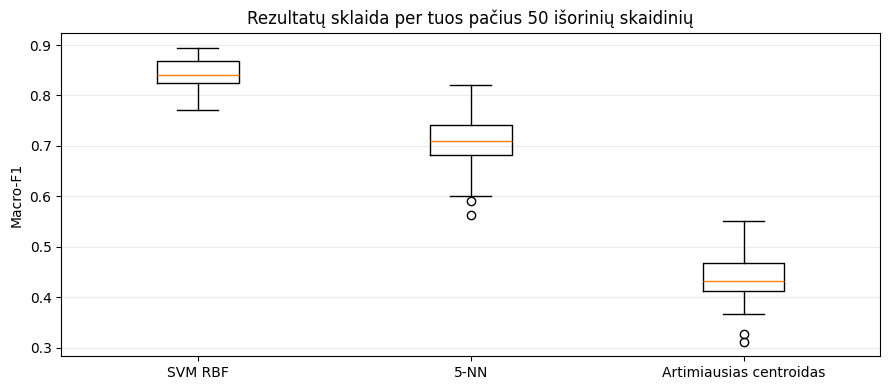

In [3]:
table(data, [method, 'knn', 'centroid'])
comparison_plot(data, [method, 'knn', 'centroid'])

## Klasių metrikos ir painiavos matrica

Kiekvienas objektas teste pasirodo penkis kartus. Čia pateiktos sujungtų išorinių prognozių metrikos.

,Preciziškumas,Jautrumas,F1,Prognozių skaičius
bus,0.980,0.972,0.976,1090.0
opel,0.723,0.710,0.716,1060.0
saab,0.725,0.717,0.721,1085.0
van,0.937,0.973,0.955,995.0


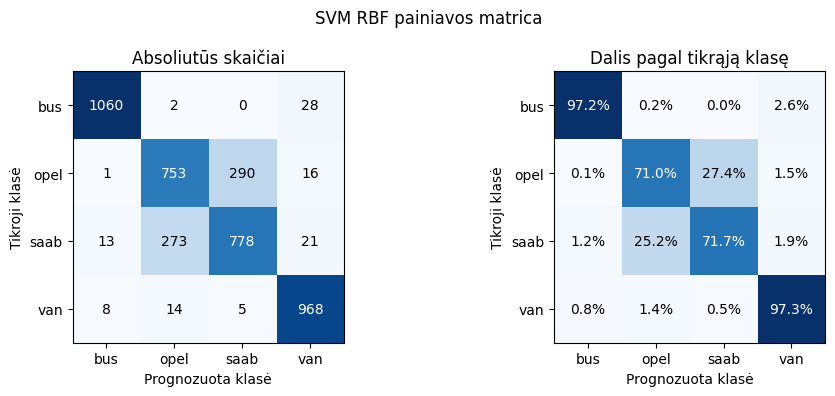

In [4]:
class_analysis(data, method)

## Dešimt klaidų pavyzdžių

Rodomi skirtingi įrašai ir dažniausia jų klaidinga klasė; vienodi dažniai sprendžiami pagal klasių tvarką. Tai klaidų pasikartojimo, ne užtikrintumo reitingas. Pradinių siluetų vaizdų faile nėra.

,Tikroji klasė,Dažniausia klaidinga klasė,Šios klaidos kartai,Visos klaidos iš 5
Įrašo indeksas,,,,
21,van,opel,5,5
23,bus,van,5,5
26,saab,opel,5,5
31,saab,van,5,5
32,opel,saab,5,5
58,opel,saab,5,5
65,opel,saab,5,5
72,opel,saab,5,5
77,saab,bus,5,5


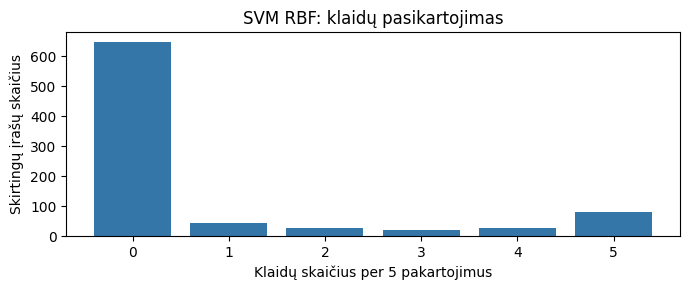

In [5]:
error_examples(data, method)

## Atsparumas triukšmui ir trūkstamiems požymiams

Trikdžiai taikyti tik išoriniam testui: trys triukšmo lygiai, 5 % ir 10 % trūkstamų langelių, po 20 realizacijų. Visi metodai gavo tuos pačius trikdžius. Lentelėje – šis metodas, grafike – ir baseline.

Macro-F1  Balanced accuracy  Macro-F1 kritimas
kind    level                                                
missing 0.05     0.7756             0.7765             0.0661
        0.10     0.7241             0.7241             0.1176
noise   0.05     0.8327             0.8347             0.0089
        0.10     0.8176             0.8193             0.0241
        0.20     0.7652             0.7662             0.0765

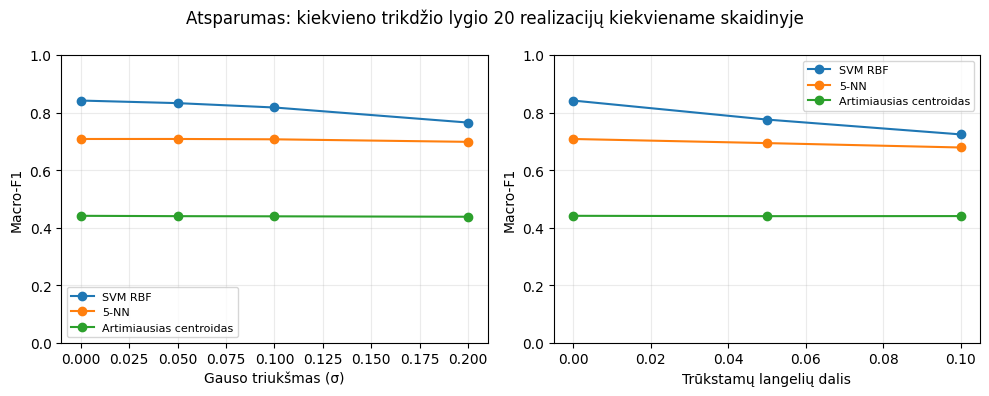

In [6]:
robustness_analysis(data, method)

## Eksperimento abliacija ir požymių jautrumas

Ši užduoties dalis atlikta pagrindiniam **SVM**. MLP ir RBF sąsiuviniuose tai bendro eksperimento kontekstas, ne šių alternatyvų abliacija. Permutacija ir vieno požymio visiškas trūkumas yra atskiri trikdžiai.

,Macro-F1 ± SD,Balanced accuracy ± SD,"Mokymas su paieška, s"
Metodas,,,
SVM RBF,0.842 ± 0.031,0.843 ± 0.030,3.812
Tiesinis SVM,0.794 ± 0.036,0.797 ± 0.036,2.012
SVM be standartizavimo,0.756 ± 0.040,0.765 ± 0.037,5.031


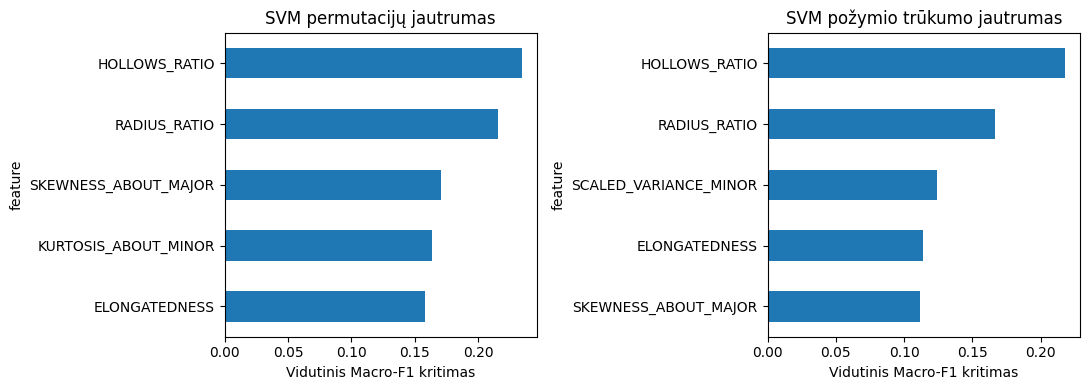

In [7]:
ablations(data)

## Formulė ir konkreti kodo vieta

$K(z,z')=\exp(-\gamma\|z-z'\|^2)$, kur $z$ – mokymo dalyje standartizuoti požymiai, $\gamma$ valdo branduolio plotį. `src/models.py::build_pipeline` sukuria `SVC(kernel="rbf", decision_function_shape="ovo")`; `grid_for` perduoda `C` ir `gamma` vidinei paieškai. `C` valdo minkšto tarpo klaidų baudą. Keturioms klasėms gaunami šeši poriniai klasifikatoriai. Diagnostiniai balai nėra tikimybės; balsų lygybę sprendžia bibliotekos numatytoji taisyklė.

In [8]:
import inspect
from src.models import build_pipeline, EncodedMLP, RBFNetwork
# Tikras naudojamos realizacijos kodas.
print(inspect.getsource(build_pipeline))

def build_pipeline(name: str, seed: int, *, scaled=True):
    if name == "centroid":
        model = NearestCentroid(metric="euclidean", shrink_threshold=None)
    elif name == "knn":
        model = KNeighborsClassifier(n_neighbors=5, metric="euclidean", weights="uniform")
    elif name == "svm":
        # SVC naudoja minkšto tarpo optimizavimą ir exp(-gamma ||z-z'||²) branduolį.
        # OVO balsų lygybę sprendžia bibliotekos predict; balai nėra tikimybės.
        model = SVC(kernel="rbf", decision_function_shape="ovo", random_state=seed)
    elif name == "svm_linear":
        model = SVC(kernel="linear", decision_function_shape="ovo", random_state=seed)
    elif name == "mlp":
        model = EncodedMLP(random_state=seed)
    elif name == "rbf":
        model = RBFNetwork(random_state=seed)
    else:
        raise ValueError(name)
    # Imputer ir scaler išmoksta parametrus tik fit gautoje mokymo dalyje.
    # Standartizavimas: z=(x−mokymo vidurkis)/mokymo SD.
    # Testui taikomi 

## Vertinimo protokolas ir ribos

846 įrašai, 18 požymių, keturios klasės. Visiems metodams naudoti tie patys **5 × 10 stratifikuoti išoriniai skaidiniai**. Parametrai parinkti atskira **5 dalių vidine CV** pagal Macro-F1. Medianų pildymas ir standartizavimas išmokti mokymo dalyse. Išorinis testas nenaudotas parinkimui.

**SD** yra skaidinių rezultatų standartinis nuokrypis, ne pasikliautinasis intervalas. Skaidiniai priklausomi. Klasių metrikose ir painiavos matricoje kiekvienas įrašas pasirodo penkis kartus – iš viso 4 230 prognozių vienam modeliui. Klasių metrikos skaičiuotos iš sujungtų prognozių, pagrindinis Macro-F1 – kaip 50 skaidinių vidurkis.

Tinklelių sumažinimas dėl biudžeto aprašytas [plano_patikslinimai.md](plano_patikslinimai.md). Rezultatai galioja mažam keturių modelių rinkiniui; realaus eismo ir naujų fizinių modelių veikimas nepatikrintas.

## Neprivalomas mokymo pakartojimas

Nustatykite `RUN_TRAINING = True` tik norėdami mokyti iš naujo. Tai trunka kelias minutes ir išsaugo atskirą `results/notebook_<metodas>.csv`. Visas eksperimentas: `python run_experiment.py --config configs/main.yaml`.

In [9]:
RUN_TRAINING = False
if RUN_TRAINING:
    from pathlib import Path
    import pandas as pd
    import yaml
    from src.data import load_vehicle
    from run_experiment import make_outer_splits, fit_model, metrics
    cfg = yaml.safe_load(Path('configs/main.yaml').read_text(encoding='utf-8'))
    X, y, metadata = load_vehicle(Path('data'))
    rows = []
    for split, (repeat, fold, train, test) in enumerate(make_outer_splits(X, y, cfg)):
        model, params = fit_model(method, X.iloc[train], y.iloc[train], cfg,
                                  cfg['seed'] + repeat * 100 + fold, jobs=1)
        rows.append({'split': split, 'repeat': repeat, 'fold': fold,
                     **metrics(y.iloc[test], model.predict(X.iloc[test])), 'params': str(params)})
    results = pd.DataFrame(rows)
    results.to_csv(f'results/notebook_{method}.csv', index=False)
    display(results[['macro_f1', 'balanced_accuracy']].agg(['mean', 'std']))
else:
    print('Mokymas nepaleistas. Rodomi pilno išsaugoto eksperimento rezultatai.')


Mokymas nepaleistas. Rodomi pilno išsaugoto eksperimento rezultatai.
